# Add `audio_mp3` + `audio_uuid` preview columns to a Lance dataset

End-to-end smoke run for `synth_setter.pipeline.data.add_preview_columns`:

1. Build a tiny Lance dataset with the same schema `generate-dataset` / `finalize-dataset` write (`audio` / `mel_spec` / `param_array` tensor columns plus embedded `ShardMetadata`).
2. Run the add step, which appends an `audio_mp3` Arrow binary column (tagged `mime_type: audio/mpeg`) and an `audio_uuid` string column (a deterministic UUIDv5 of each row's `audio` bytes), in one transaction.
3. Read back a dataframe of the params, each row's uuid, and its MP3 size, then decode one MP3 payload.

In [1]:
import io
import tempfile
from pathlib import Path

import lance
import numpy as np
from pedalboard.io import AudioFile

from synth_setter.data.vst.shapes import AUDIO_FIELD, MEL_SPEC_FIELD, PARAM_ARRAY_FIELD
from synth_setter.pipeline.data.add_preview_columns import (
    AUDIO_MP3_FIELD,
    AUDIO_UUID_FIELD,
    add_preview_columns,
)
from synth_setter.pipeline.data.lance_shard import (
    lance_schema,
    record_batch_from_arrays,
    write_lance_dataset,
)
from synth_setter.pipeline.schemas.shard_metadata import ShardMetadata

## 1. Build a smoke Lance dataset

Four rows of stereo sine tones (one pitch per row) plus dummy mel/param tensors. The sample rate lives in the shard metadata, exactly as the real writers emit it.

In [2]:
SAMPLE_RATE = 16000
CHANNELS = 2
DURATION_SECONDS = 0.25
TIME_SAMPLES = int(SAMPLE_RATE * DURATION_SECONDS)
NUM_PARAMS = 5
FREQS = [220.0, 330.0, 440.0, 660.0]
ROWS = len(FREQS)

field_shapes = {
    AUDIO_FIELD: (ROWS, CHANNELS, TIME_SAMPLES),
    MEL_SPEC_FIELD: (ROWS, CHANNELS, 4, 4),
    PARAM_ARRAY_FIELD: (ROWS, NUM_PARAMS),
}

t = np.arange(TIME_SAMPLES) / SAMPLE_RATE
mono = np.stack([0.5 * np.sin(2 * np.pi * f * t) for f in FREQS])[:, None, :]
audio = np.broadcast_to(mono, field_shapes[AUDIO_FIELD]).astype(np.float16)

arrays = {
    AUDIO_FIELD: audio,
    MEL_SPEC_FIELD: np.zeros(field_shapes[MEL_SPEC_FIELD], dtype=np.float32),
    # Distinct per-row params so the final dataframe is legible.
    PARAM_ARRAY_FIELD: np.linspace(0, 1, ROWS * NUM_PARAMS, dtype=np.float32).reshape(
        field_shapes[PARAM_ARRAY_FIELD]
    ),
}

metadata = ShardMetadata(
    velocity=100,
    signal_duration_seconds=DURATION_SECONDS,
    sample_rate=SAMPLE_RATE,
    channels=CHANNELS,
    min_loudness=-55.0,
)

tmpdir = tempfile.mkdtemp(prefix="preview-columns-smoke-")
uri = Path(tmpdir) / "shard-000000.lance"
schema = lance_schema(field_shapes, metadata)
write_lance_dataset(uri, schema, [record_batch_from_arrays(arrays, schema)])

print("wrote", uri)
lance.dataset(str(uri)).schema

wrote /tmp/mp3-audio-smoke-z674r2zk/shard-000000.lance


[2026-06-17T00:19:37Z WARN  lance::dataset::write::insert] No existing dataset at /tmp/mp3-audio-smoke-z674r2zk/shard-000000.lance, it will be created


audio: extension<arrow.fixed_shape_tensor[value_type=halffloat, shape=[2,4000]]> not null
mel_spec: extension<arrow.fixed_shape_tensor[value_type=float, shape=[2,4,4]]> not null
param_array: extension<arrow.fixed_shape_tensor[value_type=float, shape=[5]]> not null
-- schema metadata --
synth_setter.shard_metadata: '{"velocity":100,"signal_duration_seconds":0' + 98

## 2. Run the add step

`add_preview_columns` reads the sample rate from the shard metadata, then commits both columns (`audio_mp3` binary + `audio_uuid` string) in one transaction.

In [3]:
add_preview_columns(uri, bitrate_kbps=128)

lance.dataset(str(uri)).schema

audio: extension<arrow.fixed_shape_tensor[value_type=halffloat, shape=[2,4000]]> not null
mel_spec: extension<arrow.fixed_shape_tensor[value_type=float, shape=[2,4,4]]> not null
param_array: extension<arrow.fixed_shape_tensor[value_type=float, shape=[5]]> not null
audio_mp3: extension<lance.blob.v2<BlobType>>
  -- field metadata --
  mime_type: 'audio/mpeg'
-- schema metadata --
synth_setter.shard_metadata: '{"velocity":100,"signal_duration_seconds":0' + 98

## 3. Dataframe of the params, the row uuid, and the MP3 size

In [4]:
ds = lance.dataset(str(uri))
table = ds.to_table(columns=[PARAM_ARRAY_FIELD, AUDIO_MP3_FIELD, AUDIO_UUID_FIELD])
mp3_payloads = table.column(AUDIO_MP3_FIELD).to_pylist()
df = table.drop([AUDIO_MP3_FIELD]).to_pandas()
df["mp3_bytes"] = [len(p) for p in mp3_payloads]
df

,param_array,mp3_bytes
0,"[0.0, 0.05263158, 0.10526316, 0.15789473, 0.21...",5760
1,"[0.2631579, 0.31578946, 0.36842105, 0.42105263...",5760
2,"[0.5263158, 0.57894737, 0.6315789, 0.68421054,...",5760
3,"[0.7894737, 0.84210527, 0.8947368, 0.94736844,...",5760


### Sanity check: decode one MP3 cell back to audio

Confirms the bytes are a real MP3 stream at the metadata sample rate and channel count.

In [5]:
payload = mp3_payloads[0]
with AudioFile(io.BytesIO(payload)) as f:
    decoded = f.read(f.frames)
    print(
        "sample_rate:",
        int(f.samplerate),
        "channels:",
        decoded.shape[0],
        "frames:",
        decoded.shape[1],
    )

sample_rate: 16000 channels: 2 frames: 5184


## 4. Browse the dataset in SmooSense

[SmooSense](https://smoosense.ai) renders a table as an interactive grid right
in the notebook with `Sense(df)` (per-column histograms, filters, sorting).

It **eagerly materializes every column**, so keep the raw `audio_mp3` blobs and
the `audio` / `mel_spec` fixed-shape tensors out of the projection — those
columns OOM the viewer
([#1704](https://github.com/tinaudio/synth-setter/issues/1704)). The scalar
params plus the per-row MP3 size are exactly the cheap preview SmooSense is good
at.

SmooSense also renders **every row** it is handed, so cap large shards with `.head(N)` (a no-op on these four smoke rows).

> SmooSense is an optional in-notebook viewer, not a pipeline dependency; it is installed by the project `notebooks` dependency group with the `jupyter` extra ([#1681](https://github.com/tinaudio/synth-setter/issues/1681)).

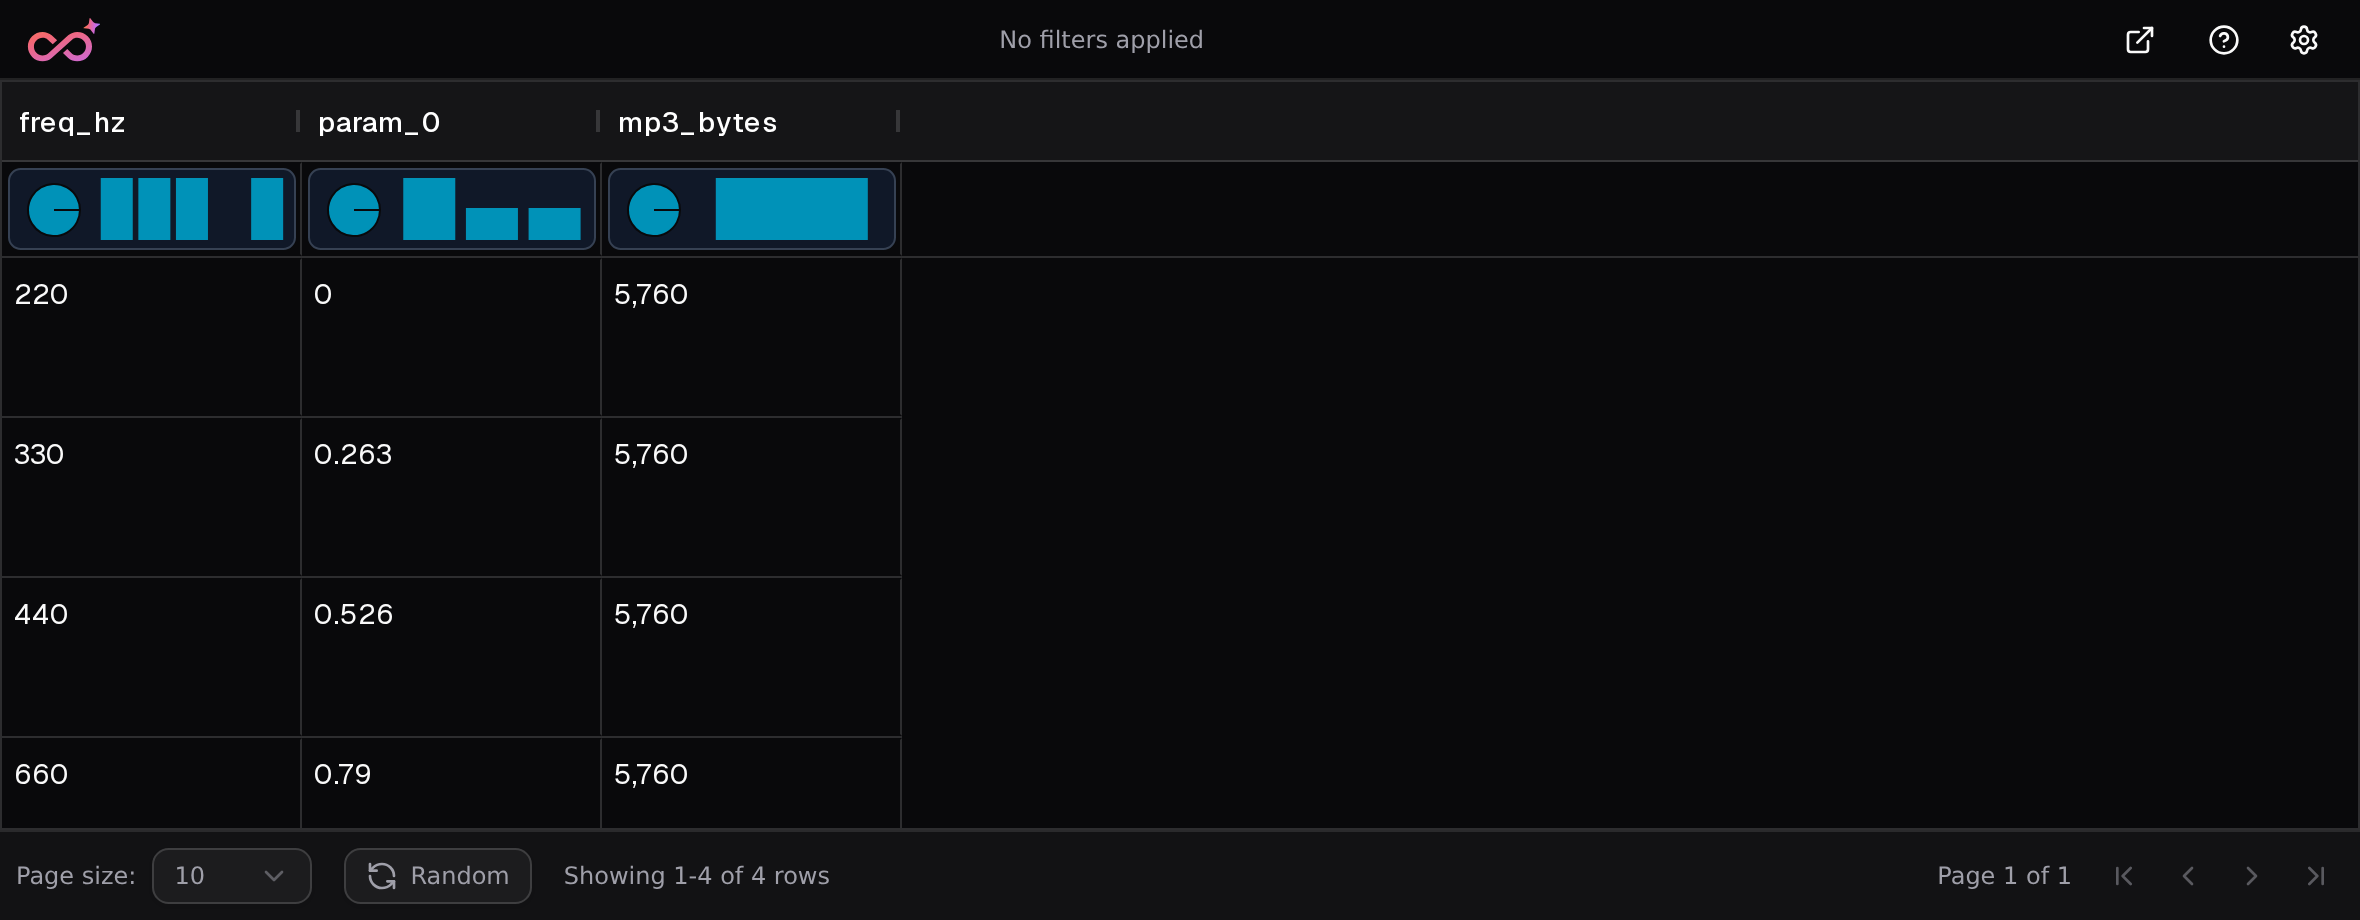

In [6]:
from smoosense.widget import Sense

# Scalar summary only — never the audio_mp3 blob or the audio/mel tensors
# (#1704). `.head()` caps rows too: SmooSense renders every row it is handed, so
# cap large shards (a no-op on these 4 smoke rows).
view = df.assign(
    freq_hz=FREQS,
    param_0=df[PARAM_ARRAY_FIELD].map(lambda p: round(float(p[0]), 4)),
)[["freq_hz", "param_0", "mp3_bytes"]].head(64)
Sense(view)